##### Lee, Keinath, Cianfarano and Brandon (2025). Identifying representational structure in CA1 to benchmark theoretical models of cognitive mapping. Neuron 113(2): 307-320. https://doi.org/10.1016/j.neuron.2024.10.027

In this notebook, we will run analyses and generate plots for panels from Figure 2, including the 3x3 paritioned rate map representational similarity matrix (RSM) for an example animal, nonmetric multidimensional scaling embedding of partitioned RSM, similarity of partitioned across all environments to same partition in square environment, the similarity of partitioned RSMs across animals and sequences, decoding of RSMs across animals, and the similarity of RSMs across animals with down-sampled populations. 

First load in all packages and functions for analyses and plotting

In [1]:
from utils import *
from plots import *

Define path where georepca1 folder is located, including dataset manually added to the georepca1/data folder
e.g., r"Users/YourName/Documents/georepca1"

In [2]:
p = r"" # add path to georepca1 folder here
os.chdir(p)

Define list of animal IDs

In [3]:
animals = ['QLAK-CA1-08', 'QLAK-CA1-30', 'QLAK-CA1-50', 'QLAK-CA1-51', 'QLAK-CA1-56', 'QLAK-CA1-74', 'QLAK-CA1-75']

### Figure 2B
Generate 3x3 Partitioned rate map representational similarity matrix
Core function (get_cell_rsm_partitioned) is defined below

In [4]:
def get_cell_rsm_partitioned(maps, down_sample_mask=None, d_thresh=0):
    """
    Compute similarity of 3x3 partitioned event rate maps for all cells (pairwise) registered across sessions.
    :param maps: event rate maps shape n bins x n bins (expects 15 x 15) x n cells x n days
    :param down_sample_mask: optional down sampling mask to match minimum number of cells across all days
    :param d_thresh: optional param to threshold minimum number of days cell must be registered to be included
    :return: cell_rsm - similarity matrix for all pairwise similarities within cells for all partitions; labels - labels
    for day and parition ID corresponding to each pairwise comparison in cell_rsm; cell_idx - which cells were included
    in analysis
    """
    # first load in either smoothed or unsmoothed rate maps depending on input arg
    # when loading in transpose the maps such that the cell and day axes come first
    maps = deepcopy(maps['smoothed']).transpose((2, 3, 0, 1))
    # then use a down-sampling mask to nan out cells if down_sample_mask is
    # provided with a masking (ncells, ndays)
    if np.any(down_sample_mask):
        maps[~down_sample_mask] = np.nan
    # transpose the rate maps back to their original order (xdim, ydim, ncell, ndays)
    maps = maps.transpose((2, 3, 0, 1))
    n_days = maps.shape[-1]
    # build partition masks for 3x3 grid comparisons (5 x 5 partitions of the 15 x 15 space)
    parts_idx = ((0, 5), (5, 10), (10, 15))
    n_parts = len(parts_idx) ** 2
    parts_mask = np.zeros((len(parts_idx)**2, maps.shape[0], maps.shape[1])).astype(bool)
    count = 0
    for x1, x2 in parts_idx:
        for y1, y2 in parts_idx:
            parts_mask[count, x1:x2, y1:y2] = True
            count += 1
    # flatten the rate maps create a mask to avoid correlating nans
    flat_maps = maps.reshape(maps.shape[0] * maps.shape[1], maps.shape[2], maps.shape[3])
    nan_idx = np.isnan(flat_maps)
    reg_idx = np.any(~nan_idx, axis=0)
    # cell_idx will show which cells were included that pass the number of days threshold (d_thresh)
    cell_idx = np.where(reg_idx.sum(axis=1) >= d_thresh)[0]
    # initialize cell-wise, partition-wise rsm
    cell_rsm = np.zeros([n_days, n_parts, n_days, n_parts, cell_idx.shape[0]])
    for c, cell in tqdm(enumerate(cell_idx), leave=True, position=0,
                        desc='Correlating partitions of rate maps across days and cell pairs'):
        for s1 in range(n_days):
            for s2 in range(n_days):
                # break similarities down by parition-wise comparison
                for p1_idx, p1_mask in enumerate(parts_mask):
                    for p2_idx, p2_mask in enumerate(parts_mask):
                        p1_map, p2_map = maps[:, :, cell, s1][p1_mask], maps[:, :, cell, s2][p2_mask]
                        if np.logical_and(np.where(~np.isnan(p1_map))[0].shape[0] >= 5,
                                          np.where(~np.isnan(p2_map))[0].shape[0] >= 5):
                            nan_mask = ~np.isnan(np.vstack((p1_map, p2_map)).sum(axis=0))
                            if nan_mask.astype(int).sum() > 1:
                                cell_rsm[s1, p1_idx, s2, p2_idx, c] = pearsonr(p1_map[nan_mask],
                                                                               p2_map[nan_mask])[0]
                        else:
                            cell_rsm[s1, p1_idx, s2, p2_idx, c] = np.nan
    # reshape cell_rsm to be n days x n parts x n_cells
    cell_rsm = cell_rsm.reshape(n_parts * n_days, n_parts * n_days, -1)
    # labels will have number labels for day and partition along each axis
    labels = np.zeros([n_days * n_parts, 2])
    c = 0
    for s in range(n_days):
        for p in range(n_parts):
            labels[c, :] = np.array([s, p])
            c += 1
    return cell_rsm, labels, cell_idx

In [5]:
# OPTIONAL. WARNING - Long run time!
# Calculate and save cell-wise, partition-wise rsm for all animals from rate map data
for animal in animals:
    dat = load_dat(animal, p, format="joblib")
    rsm_parts, rsm_labels, rsm_cell_idx = get_cell_rsm_partitioned(dat[animal]['maps'], d_thresh=0)
    rsm_dict = {'RSM': rsm_parts, 'd_labels': rsm_labels[:, 0], 'p_labels': rsm_labels[:, 1],
                'cell_idx': rsm_cell_idx, 'envs': dat[animal]['envs']}
    joblib.dump(rsm_dict, os.path.join(p, "results", f'{animal}_rsm_partitioned'))
    del dat

QLAK-CA1-08
QLAK-CA1-30
QLAK-CA1-50
QLAK-CA1-51
QLAK-CA1-56
QLAK-CA1-74
QLAK-CA1-75


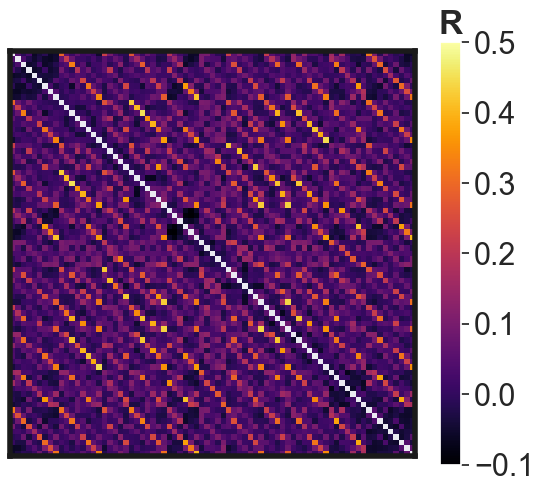

In [7]:
# Combine averaged partition-wise RSM for all animals and sequences
rsm_parts_animals = get_rsm_partitioned_sequences(animals, p)

# Order partitioned rsms across animals
rsm_parts_ordered, rsm_parts_averaged = get_rsm_partitioned_similarity(rsm_parts_animals, animals,
                                                                       False, False)
# plot resulting averaged rsm
fig_b = plot_rsm_parts_averaged(rsm_parts_averaged, vmax=0.5)

### Figure 2C
Embed partitioned RSM in 2d with non-metric multidimensional scaling

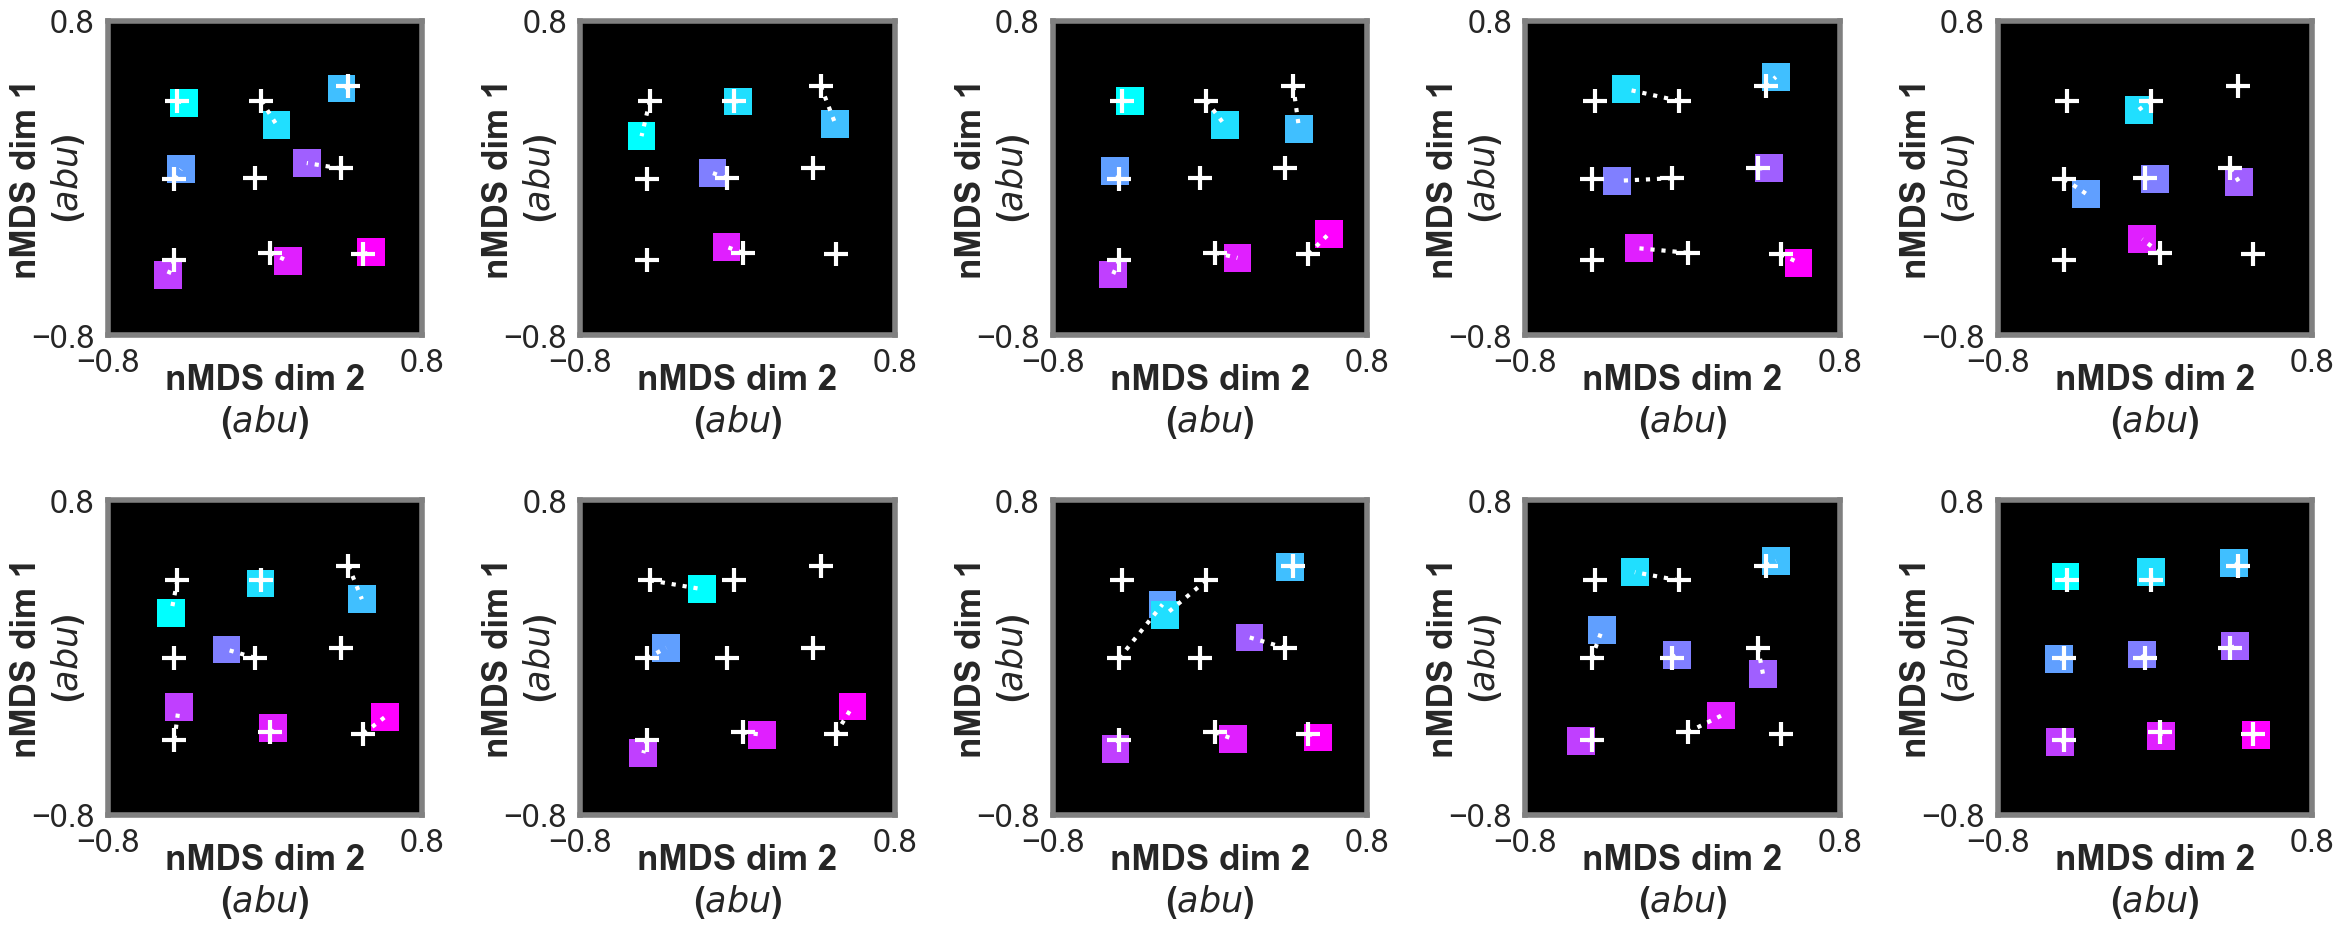

In [8]:
fig_c = plot_rsm_parts_mds(rsm_parts_averaged)

### Figure 2D
Plot the average similarity of each partition in each shape to the partition in square

QLAK-CA1-08
QLAK-CA1-30
QLAK-CA1-50
QLAK-CA1-51
QLAK-CA1-56
QLAK-CA1-74
QLAK-CA1-75


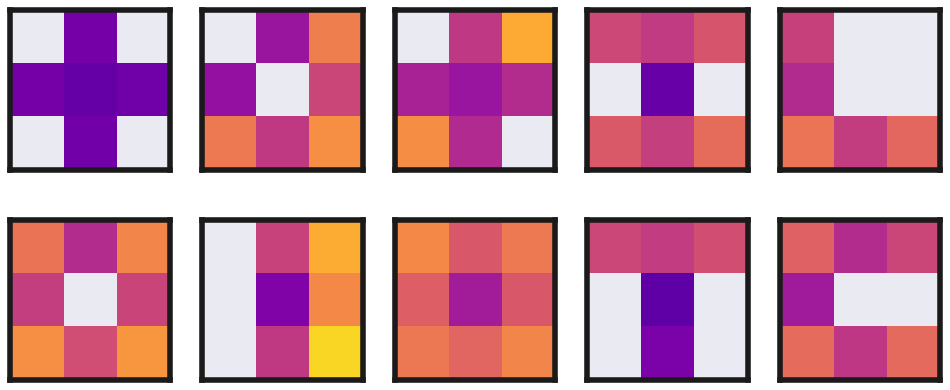

In [9]:
fig_d = plot_similarity_parts_matrix(animals, p)

### Figure 2E
Plot partitioned RSMs for two animals in each sequence

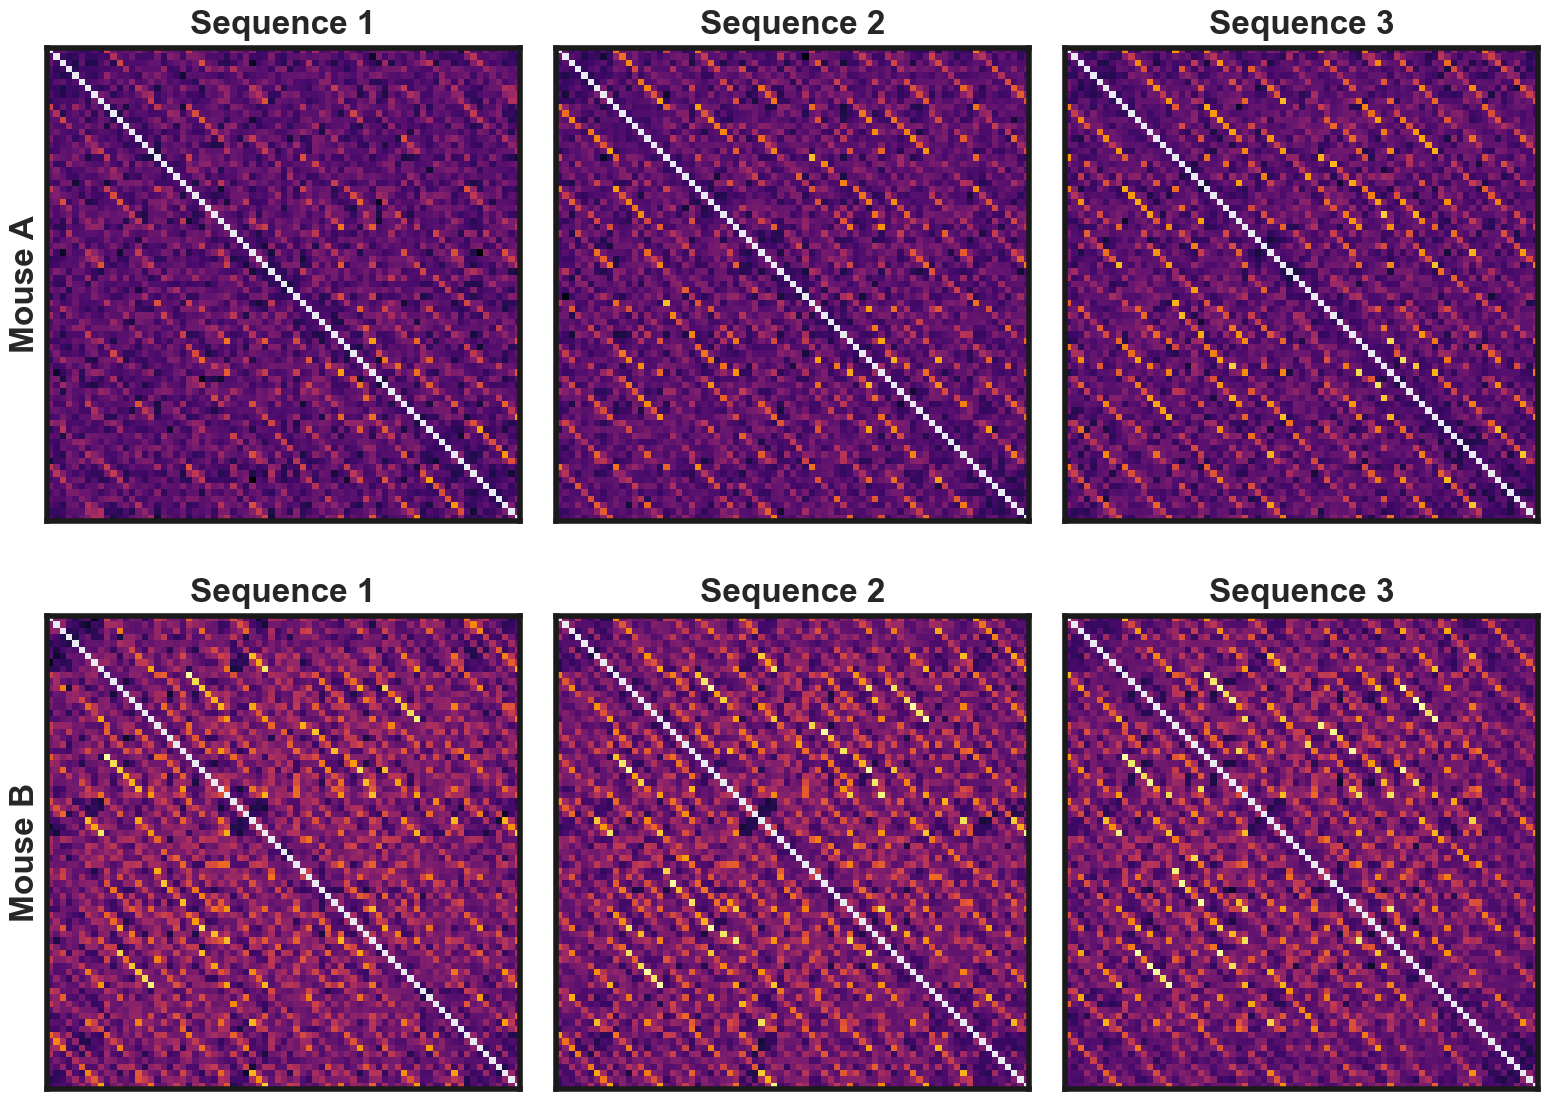

In [10]:
fig_e = plot_rsm_parts_examples(rsm_parts_ordered, 0, 2)

### Figure 2G-I
Measure the similarity of partitioned RSM across animals
Decode RSM values across animals
Decode animal identity from individual RSM

In [11]:
# plot animal-wise similarity in each sequence and decode rsm within and across animals
df_animal_similarity, df_animal_ID, df_animals, df_sequences = predict_rsm_animals(animals, rsm_parts_animals)

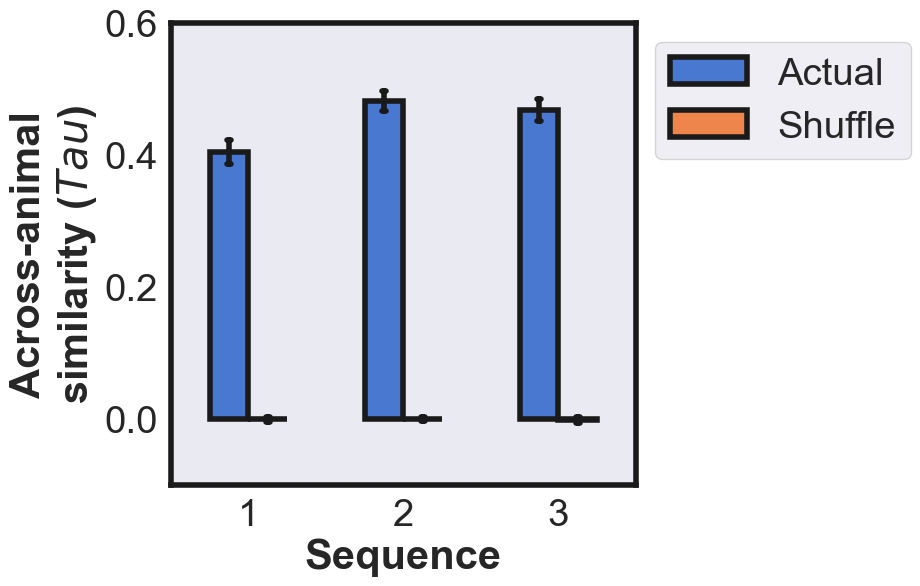

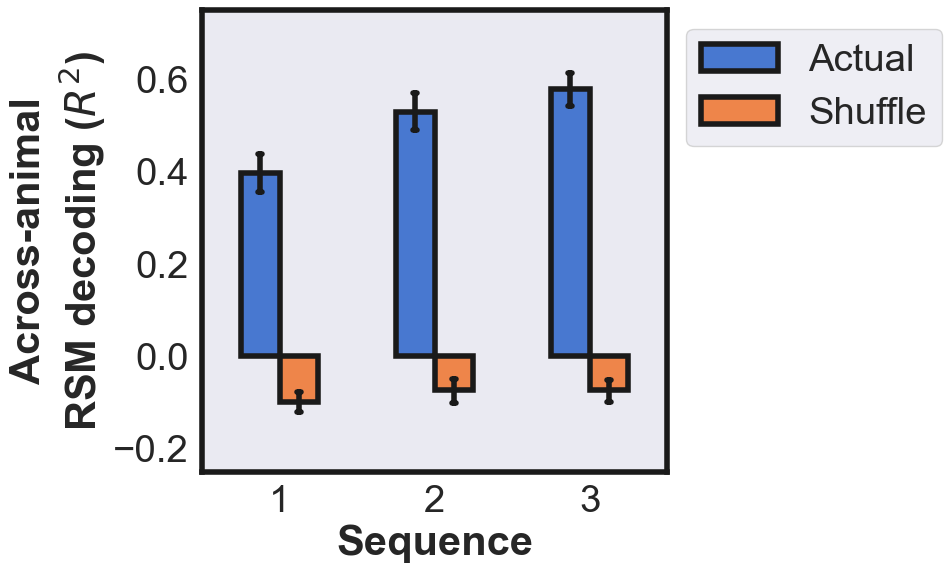

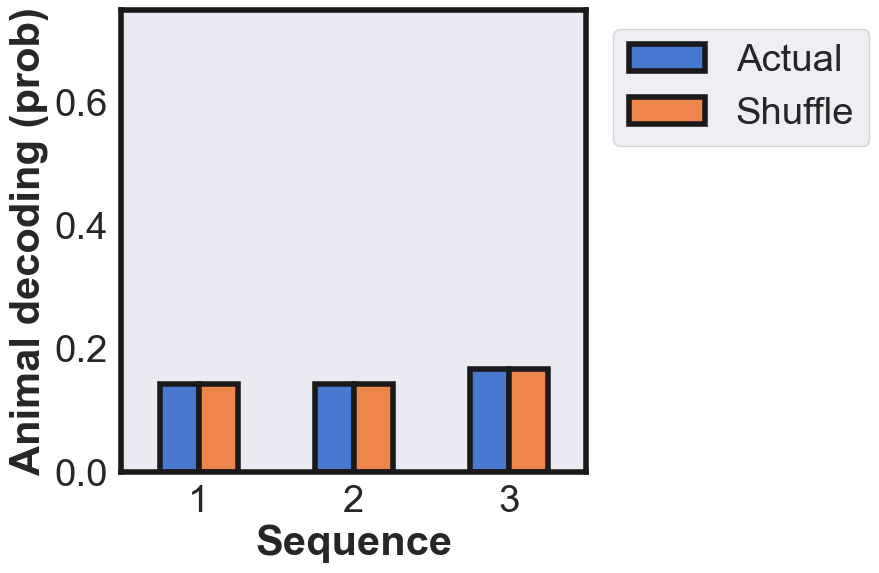

In [12]:
fig_f = plot_partitioned_rsm_similarity(df_animal_similarity)
fig_h = plot_partitioned_rsm_predictions(df_animals)
fig_i = plot_animal_id_predictions(df_animal_ID)

### Figure 2G
Measure similarity of partitioned RSM across animals, resampling different numbers of cells

In [13]:
# Figure 2g
rsm_parts_animals = get_rsm_partitioned_sequences(animals, p)
n_samples = [10, 25, 50, 100, 150, 200, 300, 400, 500, 750, 1000]
df = get_partitioned_rsm_similarity_resampled(animals, rsm_parts_animals, n_samples)

QLAK-CA1-08
QLAK-CA1-30
QLAK-CA1-50
QLAK-CA1-51
QLAK-CA1-56
QLAK-CA1-74
QLAK-CA1-75


Fitting rsm across animals with downsampling of cell numbers: 100%|██████████| 11/11 [01:12<00:00,  6.55s/it]
Fitting rsm across animals with downsampling of cell numbers: 100%|██████████| 11/11 [01:11<00:00,  6.50s/it]
Fitting rsm across animals with downsampling of cell numbers: 100%|██████████| 11/11 [01:13<00:00,  6.66s/it]
Fitting rsm across animals with downsampling of cell numbers: 100%|██████████| 11/11 [01:10<00:00,  6.39s/it]
Fitting rsm across animals with downsampling of cell numbers: 100%|██████████| 11/11 [01:10<00:00,  6.38s/it]
Fitting rsm across animals with downsampling of cell numbers: 100%|██████████| 11/11 [01:10<00:00,  6.36s/it]
Fitting rsm across animals with downsampling of cell numbers: 100%|██████████| 11/11 [01:09<00:00,  6.33s/it]
Fitting rsm across animals with downsampling of cell numbers: 100%|██████████| 11/11 [01:09<00:00,  6.32s/it]
Fitting rsm across animals with downsampling of cell numbers: 100%|██████████| 11/11 [01:11<00:00,  6.45s/it]
Fitting rs

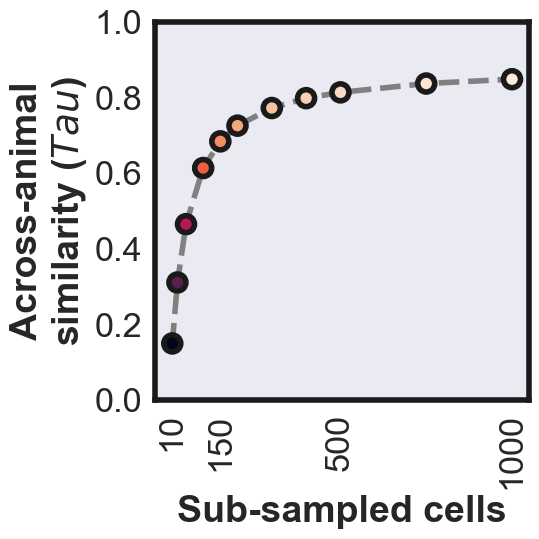

In [14]:
fig_g = plot_rsm_partitioned_similarity_resampled(df, n_samples)